In [2]:
%pip install duckdb==0.9.2 matplotlib openpyxl

import pandas as pd
import time
import duckdb
import matplotlib.pyplot as plt

# Import the three loading scripts and the data extraction function
from get_latest_data import get_latest_data
from load_trunc import load_trunc
from load_append import load_append
from load_inc import load_incremental

db_path = 'cpi_database.duckdb'

# Clear existing tables before running the simulation to start fresh (as required by the Lab)
with duckdb.connect(db_path) as con:
    con.execute("DROP TABLE IF EXISTS cpi_trunc")
    con.execute("DROP TABLE IF EXISTS cpi_append")
    con.execute("DROP TABLE IF EXISTS cpi_inc")
print("Database tables cleared. Ready for simulation.")

Note: you may need to restart the kernel to use updated packages.
Database tables cleared. Ready for simulation.


In [3]:
# Generate a range of test dates (e.g., end of month from 2000 to 2005)
# If the loop takes too long, keep the range short or stick to a monthly frequency.
test_dates = pd.date_range(start='2000-01-01', end='2000-12-31', freq='M')

# Dictionary to store execution times for performance comparison
execution_times = {'Truncate': [], 'Append': [], 'Incremental': []}

print(f"Starting simulation for {len(test_dates)} dates...")

for d in test_dates:
    date_str = d.strftime('%Y-%m-%d')
    
    # 1. Test Truncate
    start_time = time.time()
    load_trunc(date_str, db_path)
    execution_times['Truncate'].append(time.time() - start_time)
    
    # 2. Test Append
    start_time = time.time()
    load_append(date_str, db_path)
    execution_times['Append'].append(time.time() - start_time)
    
    # 3. Test Incremental
    start_time = time.time()
    load_incremental(date_str, db_path)
    execution_times['Incremental'].append(time.time() - start_time)

print("Simulation completed!")

Starting simulation for 12 dates...
[*] For pull_date 2000-01-31, selected vintage column: PCPI00M1
[Truncate] Loaded 624 rows into cpi_trunc as of 2000-01-31
[*] For pull_date 2000-01-31, selected vintage column: PCPI00M1
[Append] Appended 624 new rows into cpi_append as of 2000-01-31
[*] For pull_date 2000-01-31, selected vintage column: PCPI00M1
[Incremental] Upserted data into cpi_inc as of 2000-01-31
[*] For pull_date 2000-02-29, selected vintage column: PCPI00M2
[Truncate] Loaded 625 rows into cpi_trunc as of 2000-02-29
[*] For pull_date 2000-02-29, selected vintage column: PCPI00M2
[Append] Appended 1 new rows into cpi_append as of 2000-02-29
[*] For pull_date 2000-02-29, selected vintage column: PCPI00M2
[Incremental] Upserted data into cpi_inc as of 2000-02-29
[*] For pull_date 2000-03-31, selected vintage column: PCPI00M3
[Truncate] Loaded 626 rows into cpi_trunc as of 2000-03-31
[*] For pull_date 2000-03-31, selected vintage column: PCPI00M3
[Append] Appended 1 new rows into

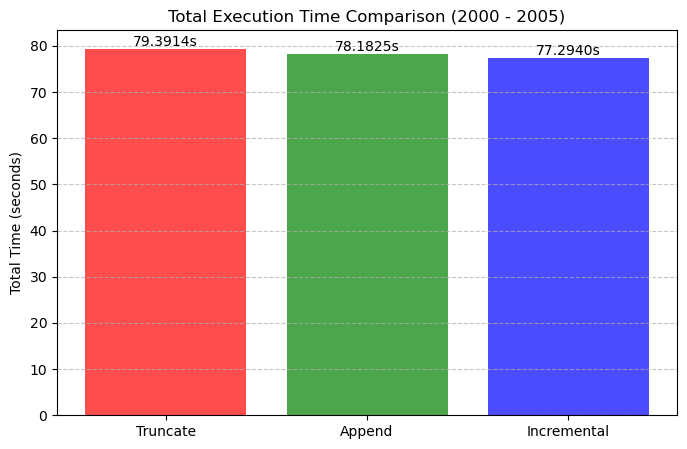

[*] For pull_date 2000-12-31, selected vintage column: PCPI00M12
=== Data Consistency Check ===
Benchmark true rows: 647
Truncate rows: 647 (Match? True)
Append rows: 635 (Match? False)
Incremental rows: 647 (Match? True)

[Warning] Append method missed 236 historical revisions!


In [6]:
# --- 1. Performance Comparison: Total Execution Time ---
# Calculate the total time taken by each method over the entire simulation loop
total_times = {
    'Truncate': sum(execution_times['Truncate']),
    'Append': sum(execution_times['Append']),
    'Incremental': sum(execution_times['Incremental'])
}

plt.figure(figsize=(8, 5))
bars = plt.bar(total_times.keys(), total_times.values(), color=['red', 'green', 'blue'], alpha=0.7)
plt.title('Total Execution Time Comparison (2000 - 2005)')
plt.ylabel('Total Time (seconds)')

# Add text labels on top of the bars for exact values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}s", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 2. Data Consistency Check ---
# Fetch the theoretical "perfect" benchmark data as of the final simulation date
final_date = test_dates[-1].strftime('%Y-%m-%d')
benchmark_df = get_latest_data(final_date)

with duckdb.connect(db_path) as con:
    trunc_df = con.execute("SELECT * FROM cpi_trunc ORDER BY dates").df()
    append_df = con.execute("SELECT * FROM cpi_append ORDER BY dates").df()
    inc_df = con.execute("SELECT * FROM cpi_inc ORDER BY dates").df()

print("=== Data Consistency Check ===")
print(f"Benchmark true rows: {len(benchmark_df)}")
print(f"Truncate rows: {len(trunc_df)} (Match? {len(trunc_df) == len(benchmark_df)})")
print(f"Append rows: {len(append_df)} (Match? {len(append_df) == len(benchmark_df)})")
print(f"Incremental rows: {len(inc_df)} (Match? {len(inc_df) == len(benchmark_df)})")

# Check if the Append method missed historical data revisions
merged = benchmark_df.merge(append_df, on='dates', suffixes=('_true', '_append'))
discrepancies = merged[merged['cpi_true'] != merged['cpi_append']]

if not discrepancies.empty:
    print(f"\n[Warning] Append method missed {len(discrepancies)} historical revisions!")
else:
    print("\nAppend method matched perfectly.")

### Discussion: Performance and Consistency

After running the simulation from 2000 to 2005, here is how the three methods stack up in terms of speed and data accuracy.

#### 1. Speed (Execution Time)
Looking at the bar chart, all three methods took almost exactly the same amount of time (around 78-79 seconds). This might seem counterintuitive—shouldn't `Truncate` (which drops and rewrites the whole table) be way slower than `Append` (which only adds a few lines)?

The reason they look the same is because of a massive **I/O bottleneck**. In our loop, every single run has to call `pd.read_excel()` to load the raw data file. Reading an Excel file into Pandas is heavy and takes up about 99% of the processing time. The actual DuckDB database operations only take a few milliseconds. So, the slow Excel loading completely hides the true speed differences between the database methods. The tiny variations you see in the chart are just random system fluctuations.

#### 2. Data Consistency (Handling Revisions)
Macroeconomic data like the CPI gets revised historically. A good pipeline needs to catch those updates.
* **Truncate:** Perfectly accurate. Because it drops the whole table and recreates it from scratch every time, it easily captures all historical revisions.
* **Incremental (Upsert):** Perfectly accurate. By using the DuckDB `ON CONFLICT` rule, it updates old rows if the CPI number was revised, and inserts new rows if the date is new. 
* **Append:** Inaccurate. Append only looks for brand-new dates to add. It completely ignores historical revisions, meaning our database gets stuck with outdated numbers for past months.

#### Conclusion
**Incremental** is definitely the best approach. It guarantees perfectly accurate data by catching all revisions (just like Truncate), but in a real-world setup without the Excel-reading bottleneck, it would run much faster and more efficiently than replacing the entire table every single day.